# Initial Load and Clean Data Frame

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\endresju\OneDrive - Jochen Schweizer mydays Holding GmbH\S_Unterlagen und Dokumente\02_Online lernen\Luke Barousse\Python for Data Analytics\data_jobs.csv")

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US.sample(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
169819,Data Analyst,Data Analyst/Help Desk,"Hialeah, FL",via Indeed,Full-time,False,"Florida, United States",2023-04-03 15:02:59,True,True,United States,year,49440.351562,NaN,Iwebgrocer,"[sql, windows, excel, trello]","{'analyst_tools': ['excel'], 'async': ['trello..."
152343,Data Analyst,Data Analyst II (Healthcare Analytics),"Lake View Terrace, CA",via FOX 5 San Diego Jobs,Full-time,False,"California, United States",2023-05-05 08:17:19,False,True,United States,year,74050.000000,NaN,Health Net,"[sql, python, r, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
410493,Data Analyst,Data Analyst,"Duluth, GA",via ZipRecruiter,Full-time,False,Georgia,2023-03-09 16:41:38,False,False,United States,year,65000.000000,NaN,Prime Care Technologies,"[sql, java, python, visual basic, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
112385,Data Analyst,Lead Data Analyst,"Long Beach, CA",via Recruit.net,Full-time,False,"California, United States",2023-01-23 00:01:11,True,False,United States,year,73481.000000,NaN,Redondo Beach,NaN,NaN
426997,Data Analyst,Business Data Analyst,"New York, NY",via Dice,Full-time,False,"New York, United States",2023-03-27 15:59:54,False,False,United States,year,90000.000000,NaN,Starr Companies,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
398464,Data Analyst,Clinical Data Analyst - C-STARS,"Baltimore, MD",via Indeed,Full-time,False,"New York, United States",2023-07-14 18:00:17,False,False,United States,year,92500.000000,NaN,"Venesco, LLC","[r, python, sas, sas, matlab, sql, tableau]","{'analyst_tools': ['sas', 'tableau'], 'program..."
725024,Data Analyst,Data Analyst,"Allentown, PA",via Dice.com,Contractor,False,"New York, United States",2023-10-04 21:00:16,False,False,United States,year,65000.000000,NaN,AaraTechnologies Inc,"[sql, r, python, excel, tableau, power bi]","{'analyst_tools': ['excel', 'tableau', 'power ..."
29327,Data Analyst,Data Analyst,"New York, NY",via Adzuna,Full-time,False,"New York, United States",2023-10-08 12:59:59,False,True,United States,year,64272.500000,NaN,"Research Foundation for Mental Hygiene, Inc.","[sql, sas, sas, python, r]","{'analyst_tools': ['sas'], 'programming': ['sq..."
544252,Data Analyst,Entry Level Data Analyst,"Atlanta, GA",via ZipRecruiter,Full-time,False,Georgia,2023-12-08 19:45:24,False,False,United States,year,67500.000000,NaN,Jumpvine,NaN,NaN
278107,Data Analyst,Data Analyst,Anywhere,via Get.It,Full-time,True,"New York, United States",2023-11-05 07:00:06,False,True,United States,year,46500.000000,NaN,Get It Recruit - Administrative,"[sas, sas, sql, oracle, excel, sharepoint]","{'analyst_tools': ['sas', 'excel', 'sharepoint..."


In [3]:
df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [7]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values('count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_US)

df_DA_skills['skill_percentage'] = (df_DA_skills['skill_count'] / DA_job_count) * 100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percentage'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


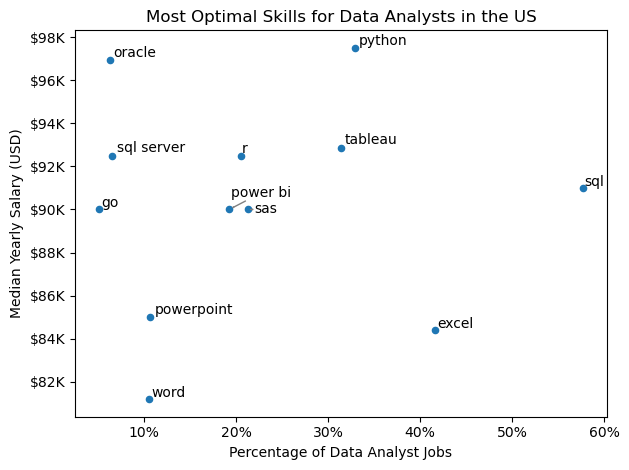

In [12]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percentage', y='median_salary')

texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')

plt.tight_layout()
plt.show()

In [13]:
df['job_type_skills'].head(10)

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: object

In [14]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['sap',
  'datarobot',
  'msaccess',
  'sheets',
  'excel',
  'spss',
  'powerpoint',
  'splunk',
  'nuix',
  'ssrs',
  'alteryx',
  'qlik',
  'cognos',
  'ssis',
  'outlook',
  'powerbi',
  'microstrategy',
  'visio',
  'tableau',
  'esquisse',
  'sharepoint',
  'sas',
  'word',
  'dax',
  'power bi',
  'ms access',
  'looker',
  'spreadsheet'],
 'programming': ['sass',
  'c',
  'golang',
  'groovy',
  'no-sql',
  'fortran',
  'r',
  'elixir',
  'bash',
  't-sql',
  'haskell',
  'vba',
  'cobol',
  'visualbasic',
  'php',
  'scala',
  'rust',
  'ocaml',
  'css',
  'sql',
  'ruby',
  'pascal',
  'erlang',
  'swift',
  'julia',
  'objective-c',
  'perl',
  'java',
  'vb.net',
  'assembly',
  'mongodb',
  'shell',
  'go',
  'delphi',
  'lua',
  'nosql',
  'f#',
  'visual basic',
  'kotlin',
  'dart',
  'clojure',
  'powershell',
  'mongo',
  'javascript',
  'sas',
  'solidity',
  'lisp',
  'c++',
  'python',
  'apl',
  'typescript',
  'crystal',
  'matlab',
  'c#',
  'h

In [15]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,sap
0,analyst_tools,datarobot
0,analyst_tools,msaccess
0,analyst_tools,sheets
0,analyst_tools,excel
...,...,...
9,sync,zoom
9,sync,unify
9,sync,microsoft teams
9,sync,symphony


In [16]:
# merge df_DA_skills and df_technology
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_DA_skills_tech

,skill_count,median_salary,skill_percentage,technology,skills
0,2508,91000.0,57.655172,programming,sql
1,1808,84392.0,41.563218,analyst_tools,excel
2,1431,97500.0,32.896552,programming,python
3,1364,92875.0,31.356322,analyst_tools,tableau
4,926,90000.0,21.287356,analyst_tools,sas
...,...,...,...,...,...
169,1,160515.0,0.022989,databases,couchbase
170,1,100000.0,0.022989,libraries,chainer
171,1,85000.0,0.022989,other,chef
172,1,113269.5,0.022989,libraries,cordova


In [18]:
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skill_percentage'] > skill_percent]

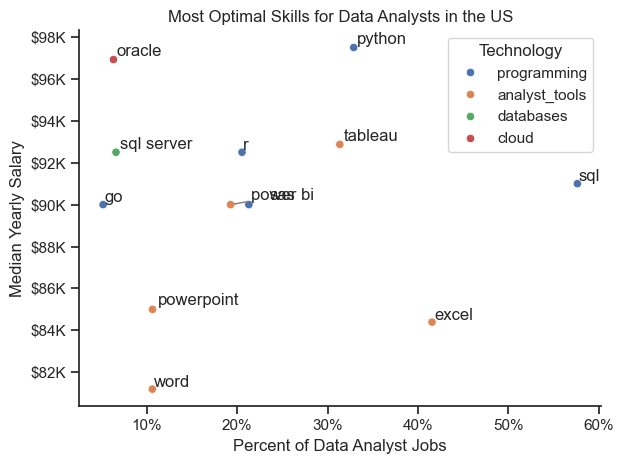

In [20]:
sns.scatterplot(
    data=df_DA_skills_tech_high_demand,
    x='skill_percentage',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()